In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

/Users/khunt/miniconda3/lib/python3.13/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


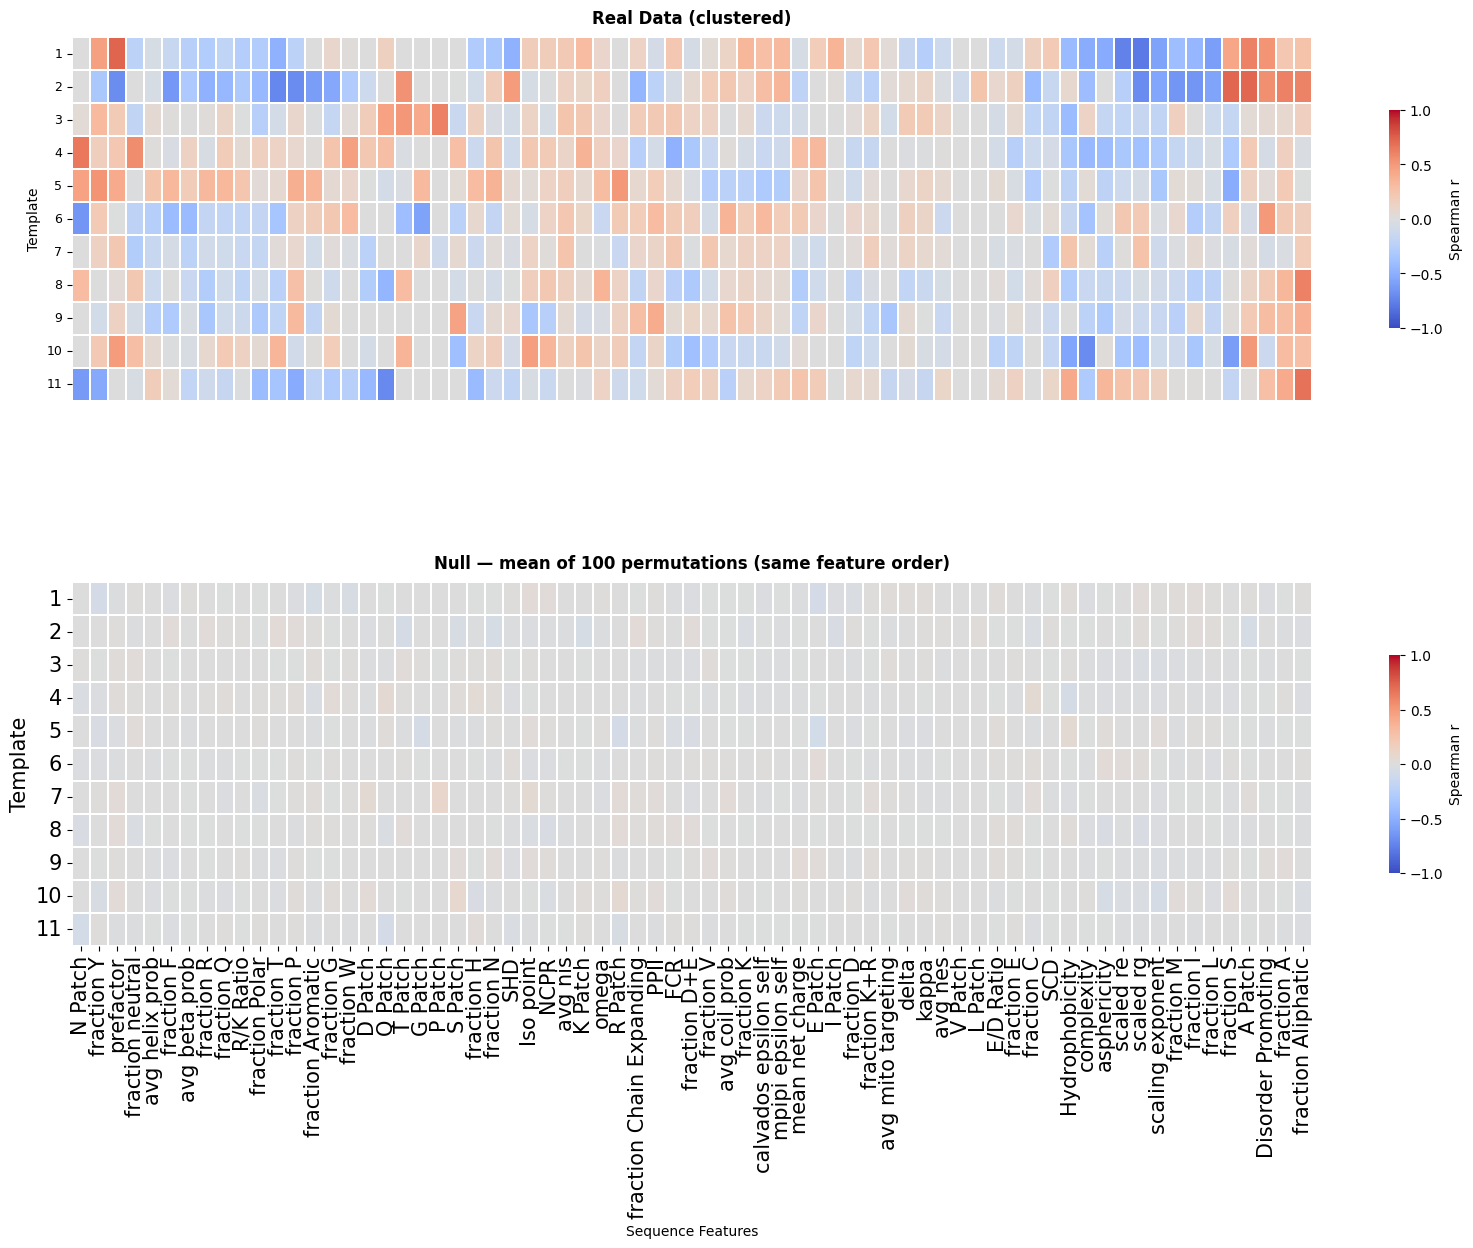

Done. Saved: clustered_r_combined (.svg + .png)


In [4]:
# ── Label simplification ──────────────────────────────────────────────────────
def simplify_label(label):
    label = re.sub(r'^(nardini_?|cider_?|sparrow_?)', '', label, flags=re.IGNORECASE)
    label = re.sub(r'_raw$', '', label)
    label = label.replace('_', ' ')
    label = re.sub(r'\bFrac\b', 'fraction', label, flags=re.IGNORECASE)
    label = re.sub(r'\s+', ' ', label).strip()
    return label

# ── Config ────────────────────────────────────────────────────────────────────
N_PERMUTATIONS = 100

row_order = [
    'syn_LEA_1', 'At2g46140_tile7', 'TgL_8x', 'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4', 'A0A438HAK2', 'Asyn_isoform_5', 'A0A1U8F7A1',
    'Os_LEA_or6', 'Os_LEA_or4', 'A0A4D6M434',
]
template_labels = [str(i + 1) for i in range(len(row_order))]

plt.rcParams['svg.fonttype'] = 'none'

# ── Load data ─────────────────────────────────────────────────────────────────
real_r = pd.read_csv('/Users/khunt/Desktop/Projects/emenecker_guadalupe_2023/Data/Figure_5/heatmap_r_mean_clustered.csv', index_col=0)
real_r = real_r.reindex(index=row_order)

null_results_df = pd.read_csv('/Users/khunt/Desktop/Projects/emenecker_guadalupe_2023/Data/Figure_5/null_permutation_averaged_results.csv')
null_r = null_results_df.pivot(index='feature', columns='base_origin', values='r_mean')
null_r = null_r[[c for c in row_order if c in null_r.columns]].dropna(how='all')
null_r = null_r.T.fillna(0).reindex(index=row_order)
null_r = null_r.reindex(columns=real_r.columns).fillna(0)

# ── Get clustered column order from real data via clustermap ──────────────────
# Run clustermap invisibly just to extract the column order
g_temp = sns.clustermap(
    real_r, method='average', metric='euclidean',
    row_cluster=False, col_cluster=True,
    cmap='coolwarm', figsize=(1, 1)
)
plt.close(g_temp.fig)  # close immediately, we only need the column order

col_order = real_r.columns[g_temp.dendrogram_col.reordered_ind]
real_ordered = real_r[col_order]
null_ordered = null_r[col_order]
simplified_col_labels = [simplify_label(c) for c in col_order]

# ── Combined figure ───────────────────────────────────────────────────────────
n_cols = len(col_order)
fig_w = max(20, n_cols * 0.2 + 3)
fig_h = len(row_order) * 0.8 + 3

fig, axes = plt.subplots(
    2, 1, figsize=(fig_w, fig_h),
    gridspec_kw={'hspace': 0.5}
)

heatmap_kws = dict(
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, cbar_kws={'label': 'Spearman r', 'shrink': 0.6}
)

# Real heatmap (top)
sns.heatmap(real_ordered, ax=axes[0], xticklabels=False,
            yticklabels=template_labels, **heatmap_kws)
axes[0].set_title('Real Data (clustered)', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('')
axes[0].set_ylabel('Template', fontsize=10)
axes[0].set_yticklabels(template_labels, fontsize=9, rotation=0)

# Null heatmap (bottom)
sns.heatmap(null_ordered, ax=axes[1], xticklabels=simplified_col_labels,
            yticklabels=template_labels, **heatmap_kws)
axes[1].set_title(f'Null — mean of {N_PERMUTATIONS} permutations (same feature order)',
                  fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Sequence Features', fontsize=10)
axes[1].set_ylabel('Template', fontsize=15)
axes[1].set_yticklabels(template_labels, fontsize=15, rotation=0)
axes[1].set_xticklabels(simplified_col_labels, rotation=90, ha='center', fontsize=15)

#plt.savefig('clustered_r_combined.svg', format='svg', bbox_inches='tight')
#plt.savefig('clustered_r_combined.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done. Saved: clustered_r_combined (.svg + .png)")

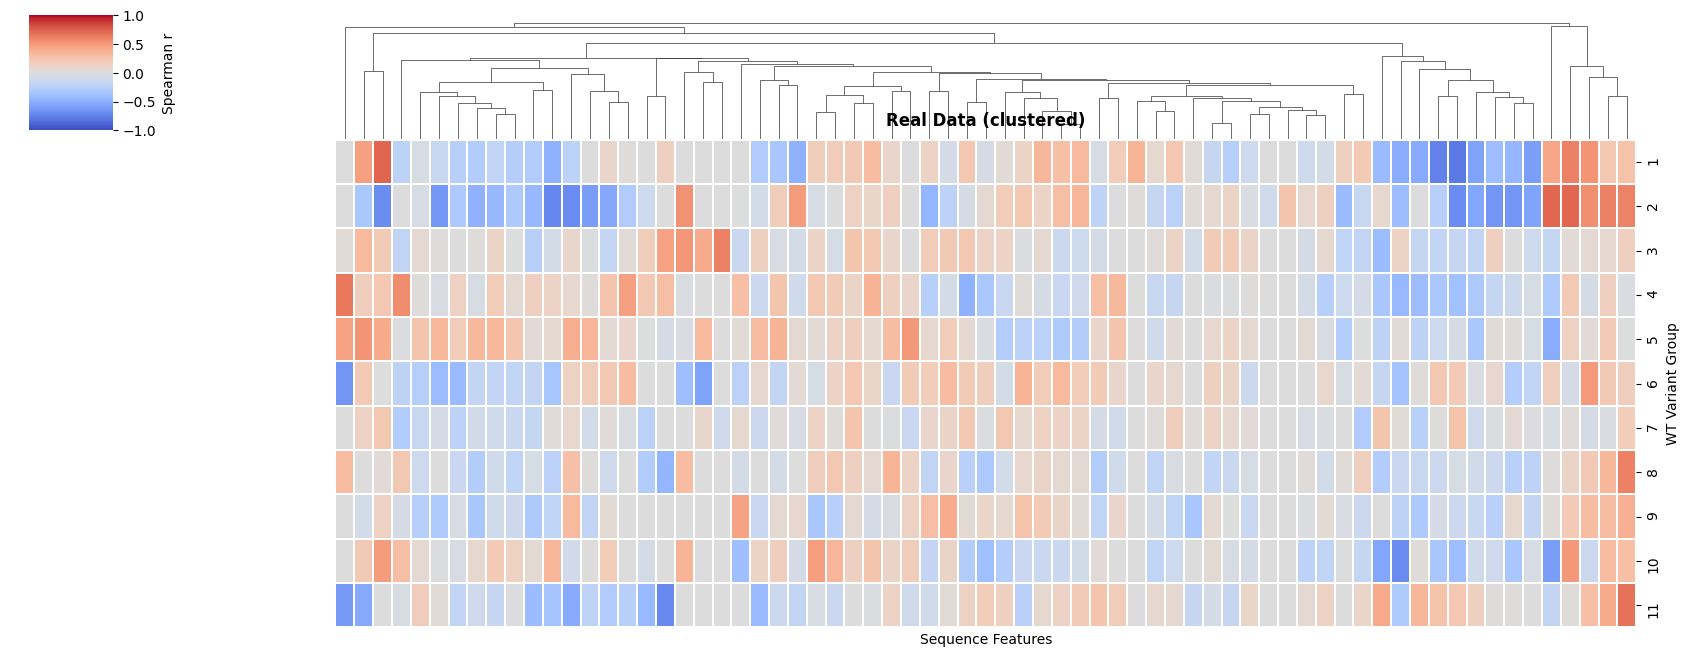

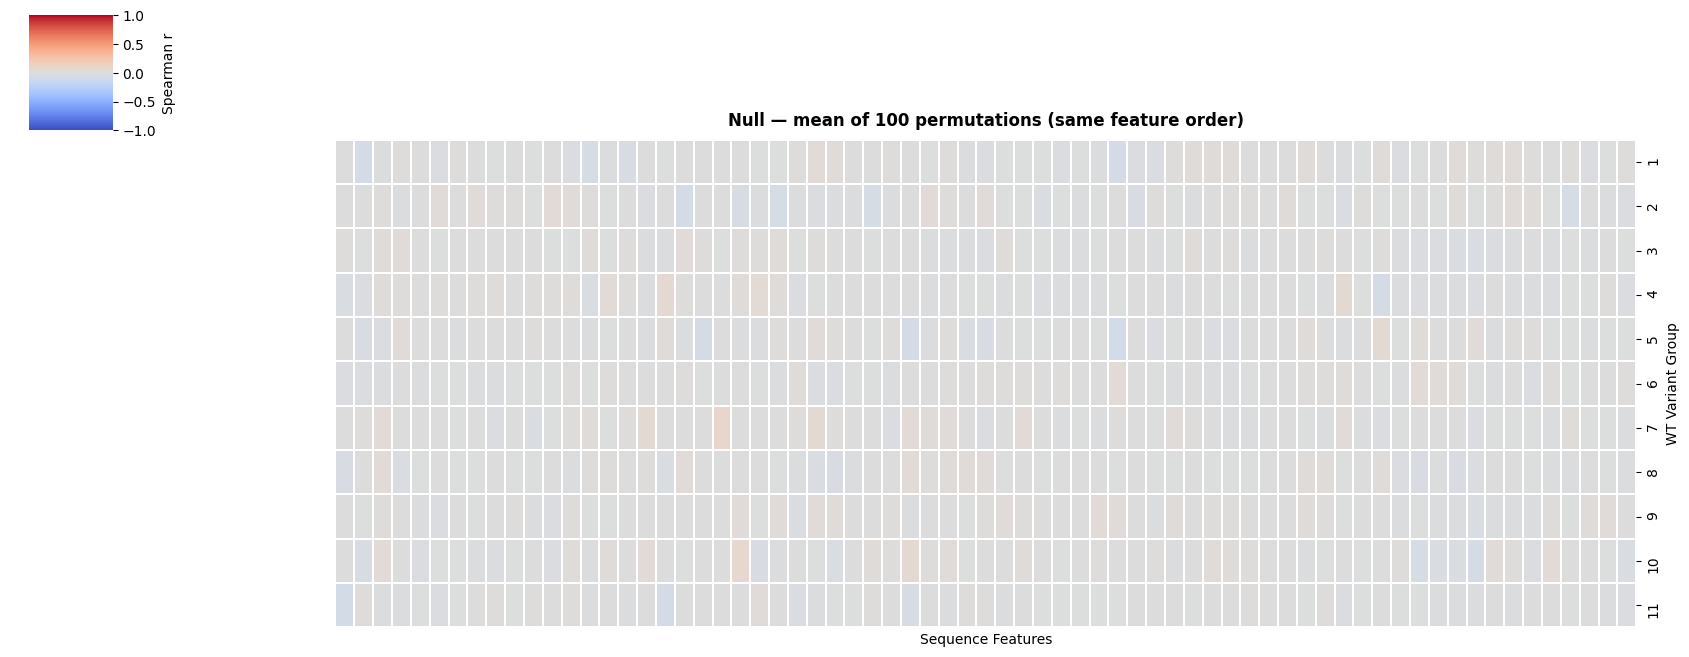

In [ ]:
##With dendrogram
# ── Config ───────────────────────────────────────────────────────────────────
N_PERMUTATIONS = 100  # update if your run used a different value

row_order = [
    'syn_LEA_1', 'At2g46140_tile7', 'TgL_8x', 'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4', 'A0A438HAK2', 'Asyn_isoform_5', 'A0A1U8F7A1',
    'Os_LEA_or6', 'Os_LEA_or4', 'A0A4D6M434',
]

numeric_labels = list(range(1, len(row_order) + 1))  # [1, 2, ..., 11]

plt.rcParams['svg.fonttype'] = 'none'

# ── Load data ─────────────────────────────────────────────────────────────────
real_r = pd.read_csv('/../../Data/Figure_5/heatmap_r_mean_clustered.csv', index_col=0)
real_r = real_r.reindex(index=row_order)
real_r.index = numeric_labels  # replace names with 1–11

null_results_df = pd.read_csv('/../../Data/Figure_5/null_permutation_averaged_results.csv')
null_r = null_results_df.pivot(index='feature', columns='base_origin', values='r_mean')
null_r = null_r[[c for c in row_order if c in null_r.columns]].dropna(how='all')
null_r = null_r.T.fillna(0).reindex(index=row_order)
null_r = null_r.reindex(columns=real_r.columns).fillna(0)
null_r.index = numeric_labels  # replace names with 1–11

# ── Shared settings ───────────────────────────────────────────────────────────
cluster_kws = dict(method='average', metric='euclidean',
                   row_cluster=False, col_cluster=True)

fig_w = real_r.shape[1] * 0.2 + 3
fig_h = len(row_order) * 0.4 + 2

# ── 1. Real data — clustered ──────────────────────────────────────────────────
g_real = sns.clustermap(
    real_r, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, figsize=(fig_w, fig_h),
    cbar_kws={'label': 'Spearman r', 'shrink': 0.6},
    xticklabels=False, yticklabels=True,
    **cluster_kws
)
g_real.ax_heatmap.set_title('Real Data (clustered)', fontsize=12, fontweight='bold', pad=10)
g_real.ax_heatmap.set_xlabel('Sequence Features', fontsize=10)
g_real.ax_heatmap.set_ylabel('WT Variant Group', fontsize=10)
#g_real.savefig('clustered_r_real.svg', format='svg', bbox_inches='tight')
#g_real.savefig('clustered_r_real.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 2. Null — same column order as real ───────────────────────────────────────
col_order = real_r.columns[g_real.dendrogram_col.reordered_ind]

g_null = sns.clustermap(
    null_r[col_order], cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, figsize=(fig_w, fig_h),
    cbar_kws={'label': 'Spearman r', 'shrink': 0.6},
    xticklabels=False, yticklabels=True,
    row_cluster=False, col_cluster=False
)
g_null.ax_heatmap.set_title(f'Null — mean of {N_PERMUTATIONS} permutations (same feature order)',
                             fontsize=12, fontweight='bold', pad=10)
g_null.ax_heatmap.set_xlabel('Sequence Features', fontsize=10)
g_null.ax_heatmap.set_ylabel('WT Variant Group', fontsize=10)
#g_null.savefig('clustered_r_null.svg', format='svg', bbox_inches='tight')
#g_null.savefig('clustered_r_null.png', dpi=150, bbox_inches='tight')
plt.show()